<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



The problem I am trying to solve is deciding which pages out of the 30,000 pages should be checked first by a FlyRank editor. The current queue uses hand-written rules and flags. I am testing whether a model can reorder the queue so that the pages with stronger signs of decline appear higher.

Each row is one page and uses its trailing 90-day data. The dataset contains 32 pseudonymized clients. The model gives a ranking score, not a final decision. The first 50 pages would be checked by an editor, who can decide whether to refresh, monitor, expand, or leave the page alone.

Editor time is limited, so I want the first 50 pages to contain as many useful cases as possible. Missing a page that is actually declining also matters. For this reason I used Precision@50 as the main metric. The main question is whether the pages at the top of the queue are actually more likely to be declining.

The current rules use fixed thresholds. They can flag a page because it is old or has a lot of impressions without considering all of its performance signals together.

One example was page `cf56e2e2e282`. It was more than 181 days old and had 61,678 impressions, so the rule marked it `HIGH_STALE_DECOY`. But the page was ranking #1 and had a 15% CTR. Those numbers suggest that the page was already performing well.

This is the type of case I wanted the model to handle better. The age signal is still useful, but it should be considered together with the other page signals.

The model is only being used to order the review queue. A high score means the page should be checked sooner. It does not explain why the page is declining and it does not decide what the editor should change.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:

#IMPORTS

import os
import json
import subprocess

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier

from IPython.display import SVG
from IPython.display import display

In [ ]:
# Step 1 — Get the Dataset

STARTER_REPO = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
if not os.path.isdir("flyrank-ml-internship-starter"):
    subprocess.run(["git", "clone", "--depth", "1", STARTER_REPO, "flyrank-ml-internship-starter"], check=True)


df = pd.read_csv("flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv")

In [ ]:
# Step 2 —  Basic dataset checks
print(df.columns)
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
print(df.shape, df["client_id"].nunique())
print(df["is_declining_label"].mean())

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')
(30000, 45) 32
0.5420666666666667


## Dataset and release

* **Release:** `content_refresh_anonymized.csv`
* The dataset contains **30,000 pages** and **44 original columns**. I added `is_declining_label`, so the dataframe has 45 columns after preprocessing.
* There are **32 pseudonymized clients**.
* The page data uses a **trailing 90-day window**.
* The target is `is_declining_label`. Its mean is **0.542**, so about 54.2% of the pages are labelled as declining.
* I did not use `trend_direction` or `trend_pct` as features because they are directly related to the label.
* I also left out the existing product scoring fields and flags used by the baseline. I wanted the model to be compared with the current rules rather than learn those rules directly.
* `client_id` is only used for grouped validation. Page IDs are not used as predictors.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

I kept the model fairly simple. The main thing I wanted to test was whether a small number of page-level signals could improve the current content-refresh queue.

The target is `is_declining_label`. A page gets a value of 1 when `trend_direction` is `"down"`. I did not use `trend_direction` or `trend_pct` as model features because they are directly related to the target.

I also left out `stale_flag`, `low_ctr_flag`, `is_decoy`, and `baseline_score`. These are part of the existing rule-based system, so using them as model inputs would make the comparison less independent.

The final features are:

* `freshness_tier_enc` — page age group.
* `avg_position` — ranking position.
* `ctr` — click-through rate.
* `impressions_90d` — impressions over the 90-day period.
* `avg_position_missing` — identifies rows where `avg_position` is 0.

I kept the existing rule-based score as the baseline. This gives me a direct comparison with the queue that the model is meant to improve.

For validation, I used 5-fold `GroupKFold` with `client_id` as the group. Pages from the same client therefore stay in the same fold. I used this instead of a normal random split because pages from the same client could otherwise appear in both training and testing.

Precision@50 is the main metric. The practical use case is a small editor queue, so I care about how many of the first 50 ranked pages are labelled as declining.

I also tested for leakage. I first checked that the banned and baseline columns were not in the feature list. Then I ran a separate test where `trend_pct` was deliberately added to the features. This should make the result much better if the evaluation is picking up target information.

The normal feature set scored **0.872 ± 0.069**. After adding `trend_pct`, the score became **1.000 ± 0.000**. This confirms that `trend_pct` gives the model information about the target, so it was kept out of the final model.


In [ ]:
#Initialize the feature encoding
tier_order = ["0-30", "31-90", "91-180", "181+"]

df["freshness_tier_enc"] = df["freshness_tier"].map(
    {tier: i for i, tier in enumerate(tier_order)}
)

In [ ]:
# flag missing position
df["avg_position_missing"] = (
    df["avg_position"] == 0
).astype(int)

In [ ]:
# baseline thresholds
STALE_TIERS = ["91-180", "181+"]
CTR_THRESHOLD = 0.005
IMPRESSION_DECOY_LEVEL = 5000

In [ ]:
# baseline flags
df["stale_flag"] = df["freshness_tier"].isin(STALE_TIERS)

df["low_ctr_flag"] = (
    (df["avg_position"] <= 20)
    & (df["ctr"] < CTR_THRESHOLD)
    & (df["impressions_90d"] >= 500)
)

df["is_decoy"] = (
    (df["freshness_tier"] == "181+")
    & (df["impressions_90d"] >= IMPRESSION_DECOY_LEVEL)
)

In [ ]:
# calculate baseline score
def calculate_score(row):
    if row["is_decoy"]:
        return 3
    if row["stale_flag"] and row["low_ctr_flag"]:
        return 2
    if row["stale_flag"] or row["low_ctr_flag"]:
        return 1
    return 0

df["baseline_score"] = df.apply(
    calculate_score,
    axis=1
)

In [ ]:
# grouped validation
N_SPLITS = 5

gkf = GroupKFold(
    n_splits=N_SPLITS
)

In [ ]:
#Initialize Precision@50
def precision_at_k(
    sub_df,
    score_col,
    k=50,
    tiebreak_col="impressions_90d"
):
    ranked = sub_df.sort_values(
        [score_col, tiebreak_col],
        ascending=[False, False]
    )

    top_k = ranked.head(k)

    return top_k["is_declining_label"].mean()

In [ ]:
#Initialize your FINAL feature list
FEATURES = [
    "freshness_tier_enc",
    "avg_position",
    "ctr",
    "impressions_90d",
    "avg_position_missing"
]

In [ ]:
print("\nFinal features:")
print(FEATURES)


Final features:
['freshness_tier_enc', 'avg_position', 'ctr', 'impressions_90d', 'avg_position_missing']


In [ ]:
print("\nLabel counts:")
print(df["is_declining_label"].value_counts())


Label counts:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64


In [ ]:
print("\nBaseline score distribution:")
print(df["baseline_score"].value_counts().sort_index())


Baseline score distribution:
baseline_score
0    19915
1     9603
2      476
3        6
Name: count, dtype: int64


In [ ]:
print("\nGroupKFold check:")

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"]),
    start=1
):
    train_clients = set(df.iloc[train_idx]["client_id"])
    test_clients = set(df.iloc[test_idx]["client_id"])

    print(
        f"Fold {fold}: "
        f"train rows={len(train_idx)}, "
        f"test rows={len(test_idx)}, "
        f"train clients={len(train_clients)}, "
        f"test clients={len(test_clients)}, "
        f"overlap={len(train_clients & test_clients)}"
    )


GroupKFold check:
Fold 1: train rows=22992, test rows=7008, train clients=31, test clients=1, overlap=0
Fold 2: train rows=24269, test rows=5731, train clients=25, test clients=7, overlap=0
Fold 3: train rows=24247, test rows=5753, train clients=24, test clients=8, overlap=0
Fold 4: train rows=24245, test rows=5755, train clients=24, test clients=8, overlap=0
Fold 5: train rows=24247, test rows=5753, train clients=24, test clients=8, overlap=0


### Leakage Check

In [ ]:
def make_rf():
    return RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

In [ ]:
# check for leakage
# these columns should not be used in the model

# columns to exclude

BANNED = [
    "trend_direction",
    "trend_pct"
]

PRODUCT_FLAGS = [
    "stale_flag",
    "low_ctr_flag",
    "is_decoy",
    "baseline_score"
]

WINDOW_TERMS = [
    "last_30d",
    "prev_30d",
    "prev30"
]


In [ ]:
# label-related columns

banned_found = [
    col for col in FEATURES
    if col in BANNED
]


# baseline flags
product_flags_found = [
    col for col in FEATURES
    if col in PRODUCT_FLAGS
]


# overlapping time windows
window_features_found = [
    col for col in FEATURES
    if any(term in col for term in WINDOW_TERMS)
]



In [ ]:
# test leakage with trend_pct

# add trend_pct only for the leakage test
df["_leak_probe"] = df["trend_pct"]

LEAKY_FEATURES = FEATURES + ["_leak_probe"]

# use the same CV split
gkf = GroupKFold(n_splits=5)


# normal feature set
honest_p50s = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"])
):

    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    rf = make_rf()

    rf.fit(
        train_fold[FEATURES],
        train_fold["is_declining_label"]
    )

    test_fold["honest_score"] = rf.predict_proba(
        test_fold[FEATURES]
    )[:, 1]

    honest_p50s.append(
        precision_at_k(
            test_fold,
            "honest_score"
        )
    )

# add trend_pct and run it again
leak_p50s = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"])
):

    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    rf = make_rf()

    rf.fit(
        train_fold[LEAKY_FEATURES],
        train_fold["is_declining_label"]
    )

    test_fold["leak_score"] = rf.predict_proba(
        test_fold[LEAKY_FEATURES]
    )[:, 1]

    leak_p50s.append(
        precision_at_k(
            test_fold,
            "leak_score"
        )
    )




In [ ]:
# Print results
print(
    "Label-derived columns:",
    banned_found if banned_found else "CLEAN"
)
print(
    "Product/baseline flags:",
    product_flags_found if product_flags_found else "CLEAN"
)
print(
    "Overlapping-window features:",
    window_features_found if window_features_found else "CLEAN"
)

print("\nLeakage injection test")
print(
    f"Normal feature set:      "
    f"{np.mean(honest_p50s):.3f} ± {np.std(honest_p50s):.3f}"
)

print(
    f"With trend_pct injected: "
    f"{np.mean(leak_p50s):.3f} ± {np.std(leak_p50s):.3f}"
)

# remove the test column
df.drop(
    columns=["_leak_probe"],
    inplace=True
)

print("\nLeakage probe removed from dataframe.")

Label-derived columns: CLEAN
Product/baseline flags: CLEAN
Overlapping-window features: CLEAN

Leakage injection test
Normal feature set:      0.872 ± 0.069
With trend_pct injected: 1.000 ± 0.000

Leakage probe removed from dataframe.


I also tested whether the evaluation could catch target leakage instead of just assuming that the feature list was clean. I retrained the same Random Forest using the same 5-fold client-grouped split and Precision@50, but added `trend_pct` deliberately. The normal feature set scored **0.872 ± 0.069**, while the leakage version reached **1.000 ± 0.000**. That large jump shows that `trend_pct` gives the model information about the target in disguise, so including it would let the model cheat. I therefore kept it out of the final feature set; this test gives actual evidence for that decision rather than relying only on a column-name check.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
baseline_p50s = []
rf_p50s = []

gkf = GroupKFold(n_splits=5)

In [ ]:


for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df, groups=df["client_id"]),
    start=1
):
    train_fold = df.iloc[train_idx].copy()
    test_fold = df.iloc[test_idx].copy()

    # Baseline score
    baseline_p50 = precision_at_k(
        test_fold,
        "baseline_score"
    )

    baseline_p50s.append(baseline_p50)

    # Random Forest
    rf = make_rf()

    rf.fit(
        train_fold[FEATURES],
        train_fold["is_declining_label"]
    )

    test_fold["rf_score"] = rf.predict_proba(
        test_fold[FEATURES]
    )[:, 1]

    rf_p50 = precision_at_k(
        test_fold,
        "rf_score"
    )

    rf_p50s.append(rf_p50)

    print(
        f"Fold {fold}: "
        f"Baseline P@50={baseline_p50:.3f}, "
        f"RF P@50={rf_p50:.3f}"
    )

Fold 1: Baseline P@50=0.740, RF P@50=0.940
Fold 2: Baseline P@50=0.960, RF P@50=0.800
Fold 3: Baseline P@50=0.620, RF P@50=0.900
Fold 4: Baseline P@50=0.900, RF P@50=0.940
Fold 5: Baseline P@50=0.720, RF P@50=0.780


In [ ]:
fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Baseline P@50": baseline_p50s,
    "Random Forest P@50": rf_p50s
})
display(fold_results)

,Fold,Baseline P@50,Random Forest P@50
0,1,0.74,0.94
1,2,0.96,0.80
2,3,0.62,0.90
3,4,0.90,0.94
4,5,0.72,0.78


In [ ]:
# Overall results
baseline_p50 = np.mean(baseline_p50s)
baseline_p50_std = np.std(baseline_p50s)

model_p50 = np.mean(rf_p50s)
model_p50_std = np.std(rf_p50s)

base_rate = df["is_declining_label"].mean()

In [ ]:

print("\nOverall results")
print(
    f"Baseline P@50: "
    f"{baseline_p50:.3f} ± {baseline_p50_std:.3f}"
)

print(
    f"Random Forest P@50: "
    f"{model_p50:.3f} ± {model_p50_std:.3f}"
)

print(
    f"Base rate: "
    f"{base_rate:.3f}"
)


Overall results
Baseline P@50: 0.788 ± 0.124
Random Forest P@50: 0.872 ± 0.069
Base rate: 0.542


### Results

The Random Forest did better than the existing rule-based baseline overall, although the result was not the same in every fold.

| Method | Precision@50 | What it means |
|---|---:|---|
| Rule-based baseline | **0.788 ± 0.124** | About 79% of the first 50 pages were actually labelled as declining. |
| Random Forest | **0.872 ± 0.069** | About 87% of the first 50 pages were labelled as declining. |
| Base rate | **0.542** | About 54% of all pages in the dataset were labelled as declining. |

The Random Forest improved Precision@50 by approximately 8 percentage points over the rule-based baseline. Its smaller standard deviation also suggests that its results were more consistent across the five client-grouped folds.

The fold results were not perfect. The Random Forest was worse than the baseline in Fold 2 (0.800 vs 0.960), but it performed better in the other four folds. This is important because the grouped split shows that the model does not perform equally well for every client group.

Overall, the result supports using the Random Forest as a **ranking model for the editor queue**, but it does not mean that every high-ranked page is actually declining. The model is useful for prioritising which pages should be checked first, rather than making the final decision automatically.

## 5. Limitations

*What this work cannot claim.*


There are a few things I would not claim from these results.

First, this is a **correlation-based ranking model**, not a causal model. The results show which pages tend to have signals associated with the declining label. They do not show that one of these features actually caused a page to decline, and I cannot use this model to claim that it predicts or explains Google's algorithm.

Second, the evaluation uses one dataset and one 90-day data window. I did not test the model across different time periods, so I cannot say yet whether the same results would hold if search behaviour or client performance changed.

Precision@50 also depends on the size of the review queue. I used 50 because that matches the practical idea of giving an editor a small list to work through. The base rate is therefore important for context: **54.2%** of all pages are labelled as declining, compared with **87.2%** in the Random Forest's top 50 pages on average.

There is also variation between client groups. The Random Forest performed better than the baseline overall, but it was not better in every fold. This means the overall average should not be treated as a guarantee for every client.

Finally, the model is meant to help an editor decide what to look at first. It is **not a replacement for editorial judgment**. A high-ranked page still needs to be checked by a person before deciding whether it should be refreshed, monitored, expanded, or left alone.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



The model should be used to make the review queue easier to work through, rather than turning its score into an automatic action.

### 1. Review the highest-ranked pages first

**Confidence: High**

Start with the pages at the top of the model's ranking. These pages have the strongest combination of signals used by the model and are the best starting point when editor time is limited.

For rank #1 tomorrow, the FlyRank editor should open the page and check the actual search performance, content quality, intent match, and whether there is an obvious reason it may need attention. The editor then makes the final decision. The model only decides that the page is worth looking at early.

### 2. Check high-priority pages for a real content problem

**Confidence: Medium**

A high model score does not automatically mean that the page needs a full refresh. The editor should check whether the page has a genuine issue, such as outdated information, weak search intent coverage, or poor engagement compared with what would normally be expected.

If there is no clear problem, the page can be moved down or left alone instead of being changed just because the model ranked it highly.

### 3. Keep lower-ranked pages in the queue for later review

**Confidence: Medium**

Pages below the first group should not be treated as completely healthy. They are simply lower priority when compared with the pages above them.

Once the highest-priority pages have been reviewed, editors can work down the ranking and use the same checks. This keeps the model as a prioritisation tool rather than a yes/no decision system.

### What the ranking should and should not do

The ranking should answer:

> **"Which pages should I look at first?"**

It should not answer:

> **"What exactly caused this page to decline?"**

and it should not automatically decide:

> **"This page must be refreshed."**

The final action stays with the FlyRank editor.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



This section contains the figures and tables that support the results reported earlier. They are included here so that the evidence shown in the notebook matches the discussion in the paper.

In [ ]:
# Build the comparison table
comparison_table = pd.DataFrame({
    "Method": [
        "Rule-based baseline",
        "Random Forest",
        "Base rate"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50,
        base_rate
    ],
    "Std": [
        baseline_p50_std,
        model_p50_std,
        np.nan
    ]
})


In [ ]:

display( comparison_table)

,Method,Precision@50,Std
0,Rule-based baseline,0.788000,0.124322
1,Random Forest,0.872000,0.068819
2,Base rate,0.542067,NaN


In [ ]:
#display fold results table
fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Baseline P@50": baseline_p50s,
    "Random Forest P@50": rf_p50s
})



In [ ]:
display(fold_results)

,Fold,Baseline P@50,Random Forest P@50
0,1,0.74,0.94
1,2,0.96,0.80
2,3,0.62,0.90
3,4,0.90,0.94
4,5,0.72,0.78


In [ ]:
# locate charts
if os.path.isdir("flyrank-ml-internship-starter"):
    chart_dir = "flyrank-ml-internship-starter/outputs/charts"
else:
    chart_dir = "outputs/charts"

print("Chart directory:", chart_dir)

Chart directory: flyrank-ml-internship-starter/outputs/charts


In [ ]:
print(f"Found {len(os.listdir(chart_dir))} chart files")

Found 5 chart files


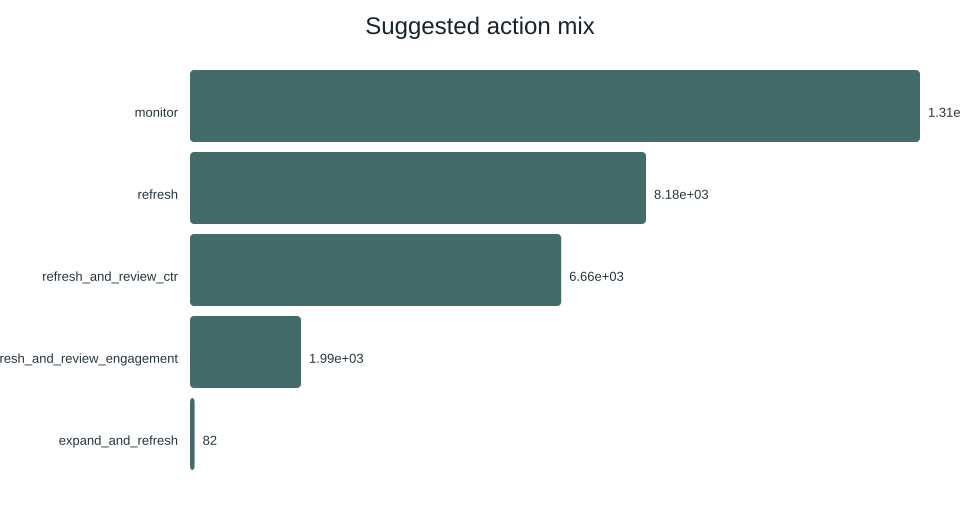

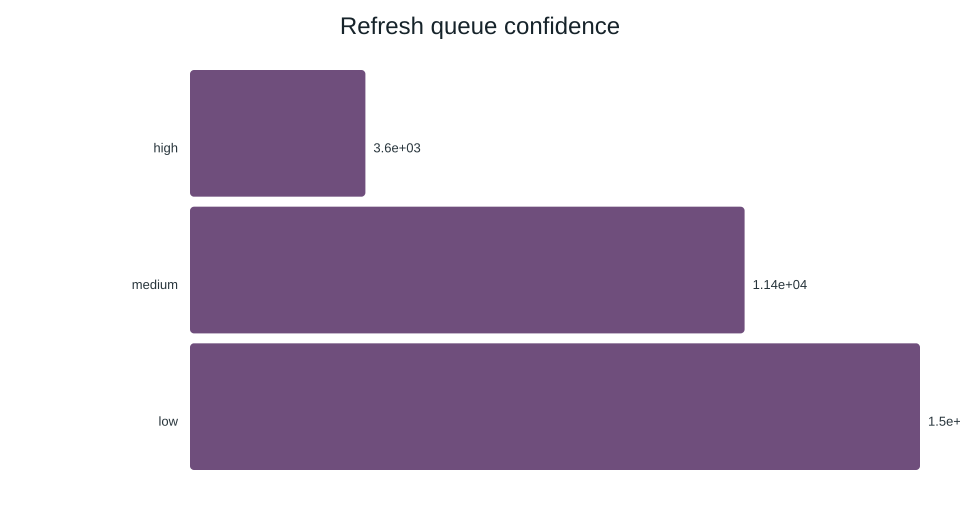

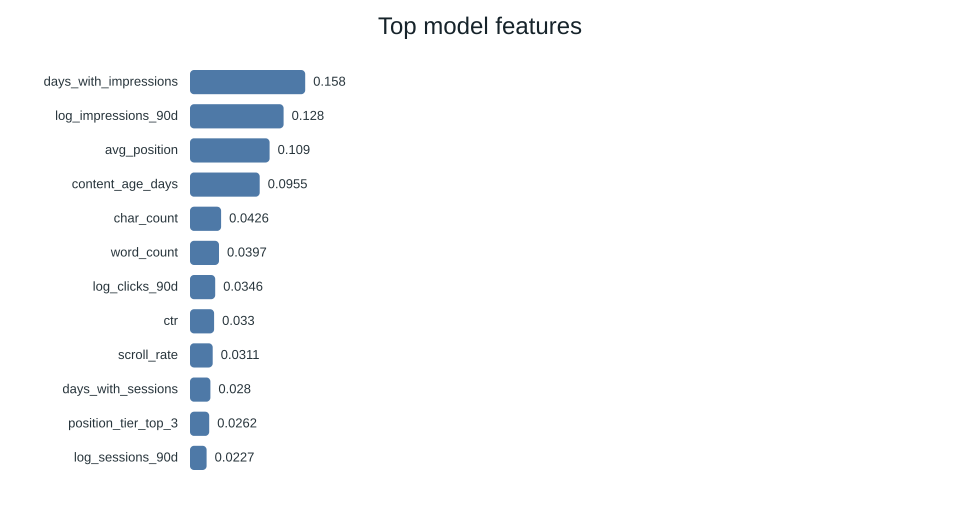

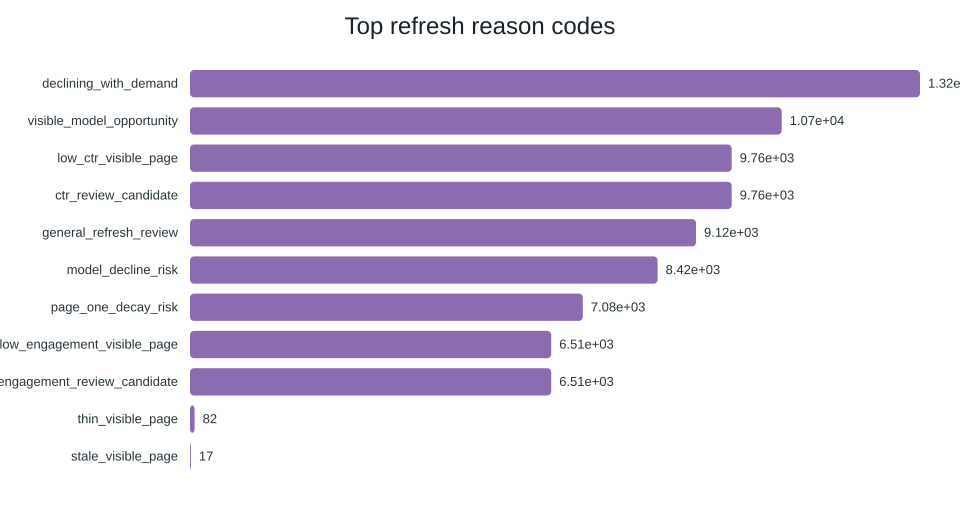

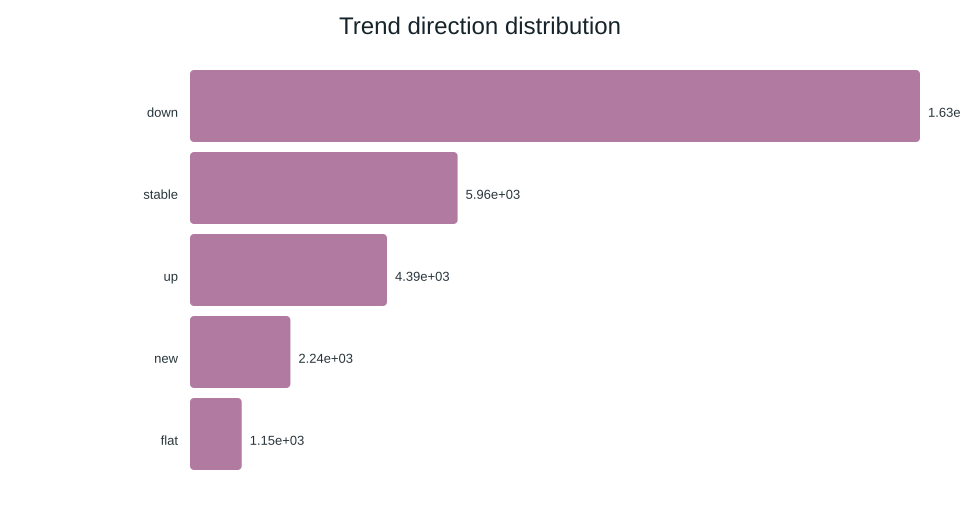

In [ ]:
display(SVG(os.path.join(chart_dir, "action_mix.svg")))
display(SVG(os.path.join(chart_dir, "confidence_mix.svg")))
display(SVG(os.path.join(chart_dir, "top_feature_importance.svg")))
display(SVG(os.path.join(chart_dir, "top_reason_codes.svg")))
display(SVG(os.path.join(chart_dir, "trend_distribution.svg")))

The tables summarise the overall evaluation, while the charts provide additional evidence about the dataset and model behaviour. Together, these artifacts support the conclusion that the Random Forest generally ranked declining pages more effectively than the rule-based baseline under grouped cross-validation.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.